----
# **<span style="color:DarkSlateBlue">PROYECTO BOOKING_REVIEWS</span>**
# **<span style="color:DarkSlateBlue">EDA</span>**
----

---
---
## <span style="color:gray">**1. Importación de librerías**</span> 📂

In [1]:
# Tratamiento de datos 
import numpy as np
import pandas as pd 

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Configuración de ruta
import sys
sys.path.append('../')

# Importación de funciones personalizadas
from src.soporte3_EDA import *
from src.soporte1_preliminar import *
from src.soporte2_limpieza import eliminar_columns

---
---
## <span style="color:gray">**2. Carga de datos**</span> 📥

In [2]:
# Utilizamos los datos que hemos guardado tras la limpieza
booking_eu = pd.read_csv("../data/output/booking_eu.csv")
reviews_limpio = pd.read_csv("../data/output/reviews_limpio.csv")

In [3]:
# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None) 

----
# <span style="color:DarkSlateBlue">**Desarrollo del proyecto - 3**</span> 
----


---
---
## <span style="color:gray">**Integración de datasets**</span> 🔗

Se ha decidido realizar una agregación previa de los datos antes de unir los datasets para garantizar la consistencia del nivel de análisis.

Inicialmente, los datos de reservas y reviews se encuentran a diferentes niveles de granularidad. Si se realizara el merge directamente, se produciría una explosión de filas (many-to-many), lo que distorsionaría medias, duplicaría observaciones y sesgaría los resultados.

Por este motivo, ambos datasets se agregan previamente a nivel de:

- fecha (`year_month`)
- país (`country`)

In [4]:
booking_agg = booking_eu.groupby(
    ['arrival_year_month', 'country']
).agg({
    # numéricas → medias
    'lead_time': 'mean',
    'stays_in_weekend_nights': 'mean',
    'stays_in_week_nights': 'mean',
    'adults': 'mean',
    'children': 'mean',
    'babies': 'mean',
    'previous_cancellations': 'mean',
    'previous_bookings_not_canceled': 'mean',
    'booking_changes': 'mean',
    'adr': 'mean',
    'total_nights': 'mean',
    'total_guests': 'mean',

    # categóricas → moda
    'hotel': lambda x: x.mode()[0],
    'meal': lambda x: x.mode()[0],
    'market_segment': lambda x: x.mode()[0],
    'is_repeated_guest': lambda x: x.mode()[0],
    'reserved_room_type': lambda x: x.mode()[0],
    'assigned_room_type': lambda x: x.mode()[0],
    'deposit_type': lambda x: x.mode()[0],
    'customer_type': lambda x: x.mode()[0],
    'reservation_status': lambda x: x.mode()[0],

}).reset_index()

In [5]:
reviews_agg = reviews_limpio.groupby(
    ['review_year_month', 'country']
).agg({
    # numéricas → medias
    'average_score': 'mean',
    'reviewer_score': 'mean',
    'total_number_of_reviews': 'mean',
    'total_number_of_reviews_reviewer_has_given': 'mean',
    'nights': 'mean',

    # categóricas → moda
    'hotel_name': lambda x: x.mode()[0],
    'reviewer_nationality': lambda x: x.mode()[0],
    'positive_tag': lambda x: x.mode()[0],
    'negative_tag': lambda x: x.mode()[0],
    'trip_type': lambda x: x.mode()[0],
    'group_type': lambda x: x.mode()[0]
}).reset_index()

In [6]:
# Unir los dataset agregados
df_final = booking_agg.merge(
    reviews_agg,
    left_on=['arrival_year_month', 'country'],
    right_on=['review_year_month', 'country'],
    how='inner'
# Eliminar una de las columnas de fecha
).drop(columns=['review_year_month'])

# Cambiar nombre de columna
df_final = df_final.rename(columns={'arrival_year_month': 'year_month'})

In [7]:
eda_preliminar(df_final)



👀 Visualización de las primeras y últimas filas



,year_month,country,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,adr,total_nights,total_guests,hotel,meal,market_segment,is_repeated_guest,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,average_score,reviewer_score,total_number_of_reviews,total_number_of_reviews_reviewer_has_given,nights,hotel_name,reviewer_nationality,positive_tag,negative_tag,trip_type,group_type
0,2015-08,austria,51.166667,1.166667,2.500000,2.000000,0.000000,0.000000,0.0,0.0,0.000000,93.166667,3.666667,2.000000,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.594389,8.438119,2354.198020,11.203520,2.790979,austria_trend_hotel_savoyen_vienna,united_kingdom,staff,other,leisure_trip,couple
1,2015-08,france,39.738889,1.005556,2.622222,1.911111,0.166667,0.011111,0.0,0.0,0.227778,108.831278,3.627778,2.088889,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.361995,8.331368,1453.671159,7.739892,2.913747,mercure_paris_terminus_nord,united_kingdom,staff,other,leisure_trip,couple
2,2015-08,italy,92.353535,1.762626,1.353535,1.939394,0.025253,0.000000,0.0,0.0,0.252525,93.021061,3.116162,1.964646,city_hotel,hb,offline_ta_to,no,a,a,no_deposit,transient_party,check_out,8.438591,8.317195,3254.060116,10.723982,2.306399,hotel_da_vinci,united_kingdom,staff,other,leisure_trip,couple


,year_month,country,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,adr,total_nights,total_guests,hotel,meal,market_segment,is_repeated_guest,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,average_score,reviewer_score,total_number_of_reviews,total_number_of_reviews_reviewer_has_given,nights,hotel_name,reviewer_nationality,positive_tag,negative_tag,trip_type,group_type
122,2017-08,italy,152.175610,1.131707,3.058537,2.053659,0.175610,0.004878,0.000000,0.019512,0.351220,156.912049,4.190244,2.234146,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.348131,8.306542,3476.593458,8.514019,2.186916,hotel_da_vinci,united_kingdom,staff,other,leisure_trip,couple
123,2017-08,netherlands,138.202128,0.829787,2.382979,2.063830,0.425532,0.000000,0.000000,0.010638,0.223404,152.198830,3.212766,2.489362,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.393452,8.375000,3594.175595,6.705357,2.693452,the_student_hotel_amsterdam_city,united_kingdom,staff,other,leisure_trip,couple
124,2017-08,spain,110.542342,1.048649,3.009009,2.073874,0.351351,0.014414,0.001802,0.003604,0.304505,201.510270,4.057658,2.439640,resort_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.494444,8.575617,2220.984568,4.765432,3.246914,ayre_hotel_gran_v_a,united_kingdom,staff,other,leisure_trip,couple




------------------------------------------------------------------------


🎲 Visualización de filas aleatorias



,year_month,country,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,adr,total_nights,total_guests,hotel,meal,market_segment,is_repeated_guest,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,average_score,reviewer_score,total_number_of_reviews,total_number_of_reviews_reviewer_has_given,nights,hotel_name,reviewer_nationality,positive_tag,negative_tag,trip_type,group_type
13,2015-10,netherlands,48.396552,1.068966,2.913793,1.862069,0.086207,0.000000,0.000000,0.000000,0.241379,90.224828,3.982759,1.948276,city_hotel,bb,online_ta,no,a,a,no_deposit,contract,check_out,8.387856,8.406448,3337.983342,7.799033,2.632456,hotel_esther_a,united_kingdom,staff,other,leisure_trip,couple
31,2016-02,france,27.841615,1.071429,2.555901,1.947205,0.139752,0.006211,0.074534,0.065217,0.192547,84.320714,3.627329,2.093168,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.426201,8.629258,1277.480349,7.929039,2.462882,mercure_paris_terminus_nord,united_kingdom,staff,other,leisure_trip,couple
70,2016-10,austria,123.388235,1.152941,2.658824,1.941176,0.223529,0.000000,0.000000,0.011765,0.494118,103.927059,3.811765,2.164706,city_hotel,bb,online_ta,no,a,d,no_deposit,transient,check_out,8.549440,8.368533,2248.676932,9.978723,2.789474,hotel_de_france_wien,united_kingdom,staff,other,leisure_trip,couple


...

Index(['year_month', 'country', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'adr', 'total_nights', 'total_guests', 'hotel',
       'meal', 'market_segment', 'is_repeated_guest', 'reserved_room_type',
       'assigned_room_type', 'deposit_type', 'customer_type',
       'reservation_status', 'average_score', 'reviewer_score',
       'total_number_of_reviews', 'total_number_of_reviews_reviewer_has_given',
       'nights', 'hotel_name', 'reviewer_nationality', 'positive_tag',
       'negative_tag', 'trip_type', 'group_type'],
      dtype='str')



------------------------------------------------------------------------


🔢 Estadísticas descriptivas de las variables numéricas



,count,mean,std,min,25%,50%,75%,max
lead_time,125.0,74.979,38.200,0.667,43.387,70.525,98.430,216.450
stays_in_weekend_nights,125.0,0.925,0.277,0.000,0.768,0.950,1.062,1.812
stays_in_week_nights,125.0,2.488,0.533,1.333,2.208,2.442,2.731,4.933
adults,125.0,1.905,0.140,1.222,1.843,1.919,1.991,2.185
children,125.0,0.114,0.087,0.000,0.045,0.097,0.167,0.426
babies,125.0,0.006,0.007,0.000,0.000,0.004,0.010,0.034
previous_cancellations,125.0,0.034,0.328,0.000,0.000,0.000,0.000,3.667
previous_bookings_not_canceled,125.0,0.028,0.121,0.000,0.000,0.008,0.024,1.333
booking_changes,125.0,0.256,0.168,0.000,0.181,0.229,0.295,1.244
adr,125.0,106.029,27.983,53.852,83.232,102.304,126.380,201.510




------------------------------------------------------------------------


🔡 Estadísticas descriptivas de las variables categóricas



,count,unique,top,freq
year_month,125,25,2015-08,5
country,125,5,austria,25
hotel,125,2,city_hotel,115
meal,125,2,bb,122
market_segment,125,4,online_ta,109
is_repeated_guest,125,1,no,125
reserved_room_type,125,1,a,125
assigned_room_type,125,2,a,123
deposit_type,125,1,no_deposit,125
customer_type,125,3,transient,111


🔢 **Variables numéricas**

| Variable | Rango / Valores | Mediana | Observaciones |
|----------|----------------|---------|---------------|
| `lead_time` | 0.67 – 216.45 | ~70.5 | Alta variabilidad; hay reservas muy anticipadas (outliers altos). |
| `stays_in_weekend_nights` | 0 – 1.81 | ~0.95 | Estancias cortas en fin de semana; baja dispersión. |
| `stays_in_week_nights` | 1.33 – 4.93 | ~2.44 | Mayor peso en noches entre semana. |
| `adults` | 1.22 – 2.18 | ~1.92 | Predominan parejas; baja variabilidad. |
| `children` | 0 – 0.43 | ~0.10 | Pocos niños; la mayoría de reservas sin menores. |
| `babies` | 0 – 0.03 | ~0.00 | Prácticamente inexistente. |
| `previous_cancellations` | 0 – 3.67 | ~0.00 | Muy pocas cancelaciones previas; algunos outliers. |
| `previous_bookings_not_canceled` | 0 – 1.33 | ~0.01 | Baja recurrencia de clientes. |
| `booking_changes` | 0 – 1.24 | ~0.23 | Pocos cambios en reservas. |
| `adr` | 53.85 – 201.51 | ~102.3 | Amplio rango de precios; segmento medio–alto. |
| `total_nights` | 1.33 – 6.62 | ~3.39 | Estancias cortas–medias; mayoría entre 2–4 noches. |
| `total_guests` | 1.22 – 2.52 | ~2.02 | Principalmente 2 personas por reserva. |
| `average_score` | 8.31 – 8.61 | ~8.44 | Muy poca variabilidad; alta satisfacción general. |
| `reviewer_score` | 7.95 – 8.83 | ~8.47 | Distribución estrecha; consistente con average_score. |
| `total_number_of_reviews` | 1119 – 3839 | ~2361 | Alta dispersión; hoteles con distinta popularidad. |
| `total_number_of_reviews_reviewer_has_given` | 4.77 – 12.34 | ~8.14 | Clientes con experiencia moderada en reviews. |
| `nights` | 2.14 – 3.37 | ~2.68 | Estancias típicas cortas; baja variabilidad. |

Se observa que las variables `total_nights` (reservas) y `nights` (reseñas) no coinciden. Esto se debe a que provienen de fuentes distintas: mientras que total_nights recoge la duración de todas las reservas, nights únicamente incluye aquellas estancias que han generado una reseña.

Por tanto, nights está sujeta a un sesgo de selección, ya que no todos los clientes dejan opiniones. Debido a esta diferencia en cobertura, ambas variables no son directamente comparables.

En consecuencia, se decide utilizar `total_nights` como medida representativa de la duración de la estancia y descartar nights para evitar inconsistencias en el análisis.

🔡 **Variables categóricas**

| Variable | Valores únicos | Moda | Observaciones |
|----------|--------------|------|---------------|
| `arrival_year_month` | 25 | 2015-08 | Distribución temporal variada. |
| `country` | 5 | Austria | Baja diversidad geográfica; posible sesgo. |
| `hotel` | 2 | city_hotel | Fuerte predominancia de hoteles urbanos. |
| `meal` | 2 | bb| Casi todos incluyen desayuno; poca variabilidad. |
| `market_segment` | 4 | online_ta | Canal dominante: agencias online. |
| `is_repeated_guest` | 1 | no | Sin variabilidad; variable irrelevante. |
| `reserved_room_type` | 1 | A | Sin variabilidad; no aporta información. |
| `assigned_room_type` | 2 | A | Muy baja variabilidad. |
| `deposit_type` | 1 | no_deposit | Sin variabilidad; eliminar. |
| `customer_type` | 3 | transient | Predominan clientes ocasionales. |
| `reservation_status` | 2 | check_out | Casi todas las reservas completadas. |
| `hotel_name` | 40 | hotel_da_vinci | Alta cardinalidad. |
| `reviewer_nationality` | 1 | United Kingdom | Sin variabilidad; eliminar. |
| `positive_tag` | 1 | staff | Sin variabilidad; no útil para análisis. |
| `negative_tag` | 1 | other | Sin variabilidad; no útil. |
| `trip_type` | 1 | leisure_trip | Sin variabilidad; eliminar. |
| `group_type` | 2 | couple | Predominan parejas. |


**Conclusiones:**

👥 **Cliente típico:** pareja en viaje de ocio

🌐 **Canal dominante:** online travel agencies

🏨 **Tipo de hotel:** urbano

⭐ **Satisfacción:** muy alta y homogénea (~8.5)

💰 **Precio:** variable pero centrado en gama media

⚠️ Se observa que el dataset presenta muchas variables sin variabilidad, por lo tanto, eliminamos estas variables del conjunto de datos para simplificar el modelo y evitar que introduzcan ruido innecesario:

- `is_repeated_guest`
- `reserved_room_type`
- `deposit_type`
- `reviewer_nationality`
- `positive_tag`
- `negative_tag`
- `trip_type`

Antes de eliminarlas, creamos una copia del DataFrame:

In [8]:
booking_reviews = df_final.copy()

- Eliminamos las varibles mencionadas anteriormente:

In [9]:
booking_reviews = eliminar_columns(booking_reviews, ['nights', 'is_repeated_guest', 'reserved_room_type', 'deposit_type', 'reviewer_nationality', 'positive_tag', 'negative_tag', 'trip_type'])

- Guardamos el DataFrame:

In [10]:
booking_reviews.to_csv("../data/output/booking_reviews.csv", index=False)

---
---
## <span style="color:gray">**EDA sobre el dataset final**</span> 🧩

---

### <span style="color:darkgray">**1. Análisis univariado**</span>  

### <span style="color:darkgray">Distribución de las columnas numéricas</span>

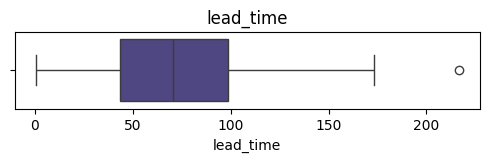

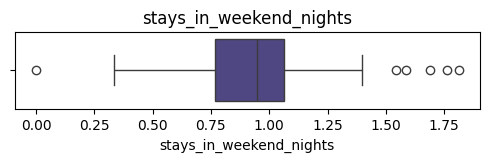

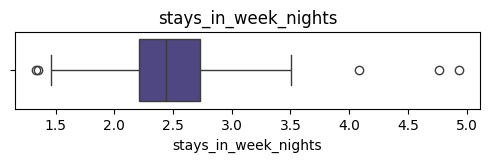

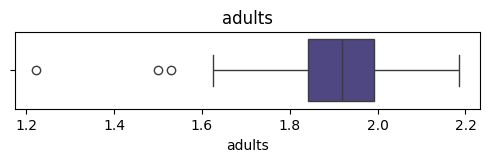

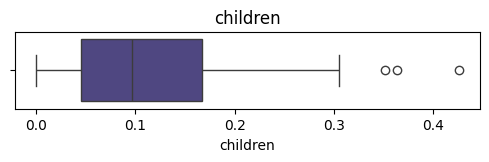

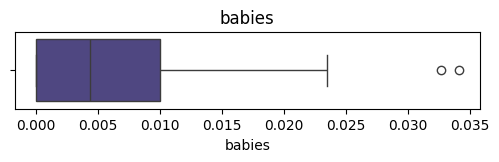

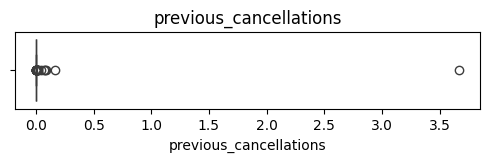

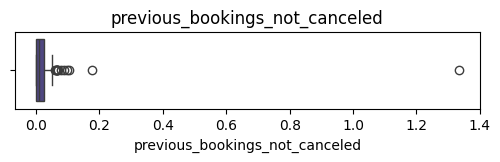

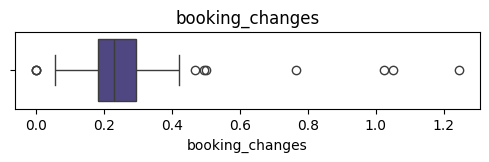

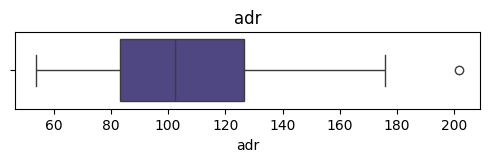

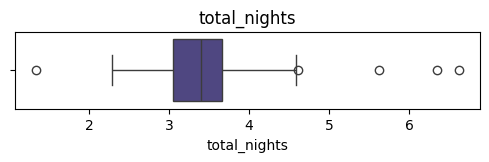

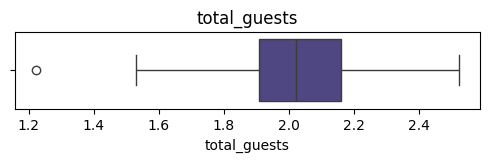

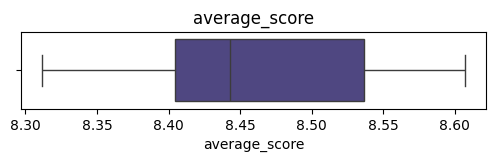

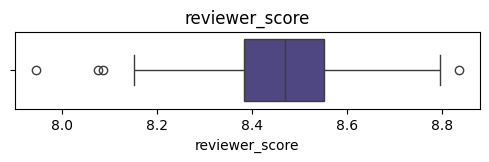

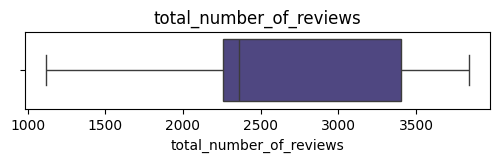

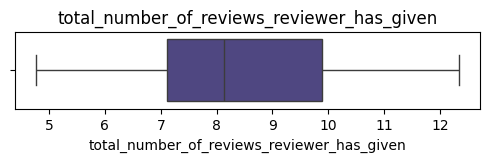

In [11]:
# Llamamos a la función de boxplots guardada en el archivo de soporte 
boxplots(booking_reviews)

El análisis univariado muestra que la mayoría de las variables numéricas presentan distribuciones sesgadas a la derecha y presencia de outliers.

- `lead_time`: bastante dispersa y con cola derecha marcada → hay reservas hechas con mucha antelación, pero no son la mayoría.
- `stays_in_weekend_nights` y `stays_in_week_nights`: concentradas en valores bajos → la mayoría de estancias son cortas.
- `adults`: muy poca variabilidad → casi siempre 2 adultos.
- `children` y `babies`: fuertemente concentradas en 0 → la mayoría de reservas no incluyen niños ni bebés.
- `previous_cancellations` y `previous_bookings_not_canceled`: muy concentradas en 0 con algunos outliers → la mayoría de clientes no tiene historial relevante, pero unos pocos sí son muy activos.
- `booking_changes`: valores bajos en general → pocas modificaciones por reserva, con algunos casos extremos.
- `adr`: dispersión moderada y algunos valores altos → existen reservas significativamente más caras que la media.
- `total_nights`: concentrada en estancias cortas (≈2–4 noches), con algunos outliers de estancias largas.
- `total_guests`: baja variabilidad → típicamente entre 1 y 2 personas.
- `average_score` y `reviewer_score`: muy concentradas en valores altos → distribuciones poco variables.
- `total_number_of_reviews`: alta dispersión → algunos hoteles tienen muchas más reseñas que otros.
- `total_number_of_reviews_reviewer_has_given`: ligera variabilidad, sin outliers extremos → comportamiento bastante homogéneo entre reviewers.

**Conclusión:**

En general, predominan reservas ‘típicas’: estancias cortas (2–4 noches), realizadas por 1–2 adultos, sin niños ni bebés y con escaso historial previo de reservas o cancelaciones. Variables como `lead_time`, `adr` y el número total de reseñas exhiben mayor dispersión y valores extremos, lo que indica la existencia de casos menos frecuentes pero relevantes (reservas con mucha antelación, precios elevados o alta actividad). Por otro lado, variables como las puntuaciones (`average_score` y `reviewer_score`) muestran baja variabilidad al concentrarse en valores altos.

---
### <span style="color:darkgray">**2. Análisis bivariado**</span>  

**2.1. Análisis de cancelaciones** ❌

Para evaluar la viabilidad del análisis de cancelaciones, se examina la distribución de la variable:

In [12]:
booking_reviews["reservation_status"].value_counts()

reservation_status
check_out    124
canceled       1
Name: count, dtype: int64

Uno de los objetivos iniciales del análisis era estudiar el comportamiento de las cancelaciones mediante la variable `reservation_status`. Sin embargo, tras el proceso de agregación y unión de los datasets de reservas y reseñas, esta variable ha quedado fuertemente desbalanceada, con una única categoría dominante (*check_out*) y una representación prácticamente nula de cancelaciones.

Este desbalance indica una pérdida de variabilidad tras la agregación, lo que impide analizar correctamente las cancelaciones en este dataset.

Por tanto:
- Se excluye `reservation_status` del análisis bivariado.
- No es adecuada como variable objetivo en este contexto.

El análisis de cancelaciones se realizará utilizando el dataset original sin agregar, donde se preserva la distribución real de la variable. Este análisis se desarrollará posteriormente en Power BI, permitiendo una exploración más detallada y segmentada.

In [13]:
# Eliminamos la columna 
booking_reviews = eliminar_columns(booking_reviews, ['reservation_status'])

In [14]:
# Guardamos el dataframe 
booking_reviews.to_csv("../data/output/booking_reviews.csv", index=False)

**2.2 Segmentación (¿quiénes son los huéspedes?)** 👥

✔ market segment vs customer type

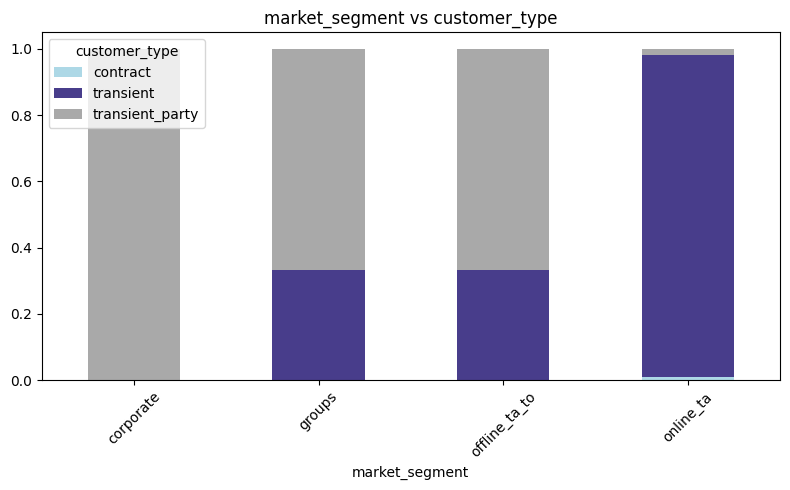

In [15]:
crosstab(booking_reviews, "market_segment", "customer_type")

Insights:
- El segmento *Online TA* está dominado por clientes *Transient*, lo que indica reservas individuales y poco compromiso a largo plazo.
- Los segmentos como *Corporate* y *Groups* muestran mayor presencia de *Contract* o clientes más estructurados.
- La baja presencia de clientes repetitivos sugiere limitada fidelización global.

Conclusión:
Las reservas dependen fuertemente de clientes no fidelizados, especialmente en canales online, lo que aumenta la volatilidad de la demanda.

**2.3. Comportamiento (¿cómo reservan los huéspedes?)** 🧠

✔ lead_time vs total_nights

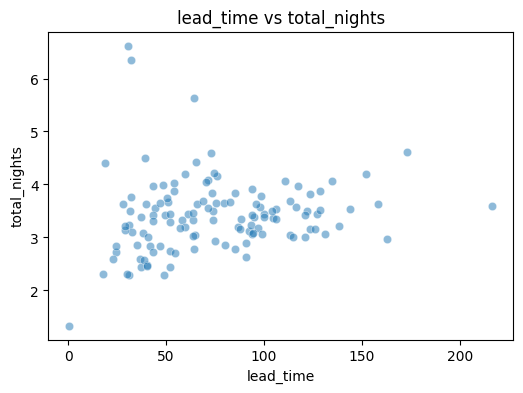

In [16]:
scatterplot(booking_reviews, "lead_time", "total_nights")

Insights:
- No hay una relación clara entre anticipación y duración de la estancia.
- Reservas largas aparecen tanto con poca como con mucha anticipación.

Conclusión:
La duración de la estancia no depende directamente del tiempo de planificación, lo que limita su uso como predictor.


✔ total_nights vs customer_type 

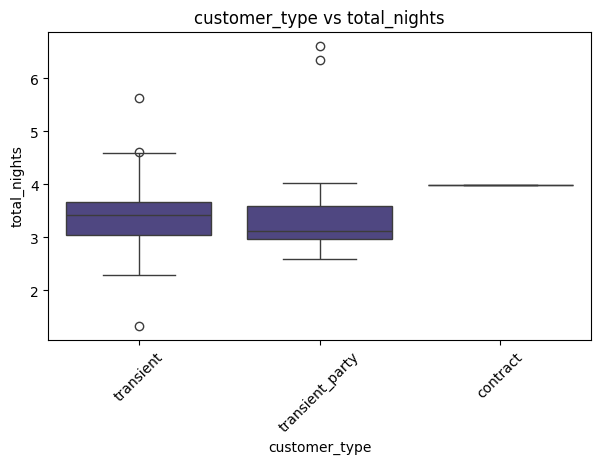

In [17]:
boxplots_bi(booking_reviews, "customer_type", "total_nights")

Insights:
- *Transient* presenta una estancia mediana ligeramente más alta y mayor variabilidad, con algunos outliers de estancias largas.
- *Transient Party* muestra estancias algo más cortas y más concentradas, aunque con algunos valores extremos.
- *Contract* es totalmente estable, con estancias prácticamente constantes.


Conclusión:
Los clientes *Transient* y *Transient Party* son más flexibles en duración de estancia, mientras que *Contract* refleja patrones fijos y predecibles.

✔ lead_time vs market_segment

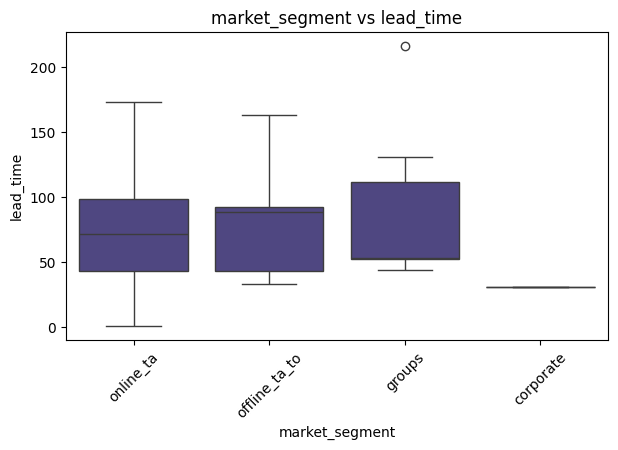

In [18]:
boxplots_bi(booking_reviews, "market_segment", "lead_time")

Insights:
- El segmento *Groups* presenta mayor lead time (reservan con más antelación).
- *Online TA* y *Transient* concentran reservas más cercanas a la fecha de llegada.

Conclusión:
Los segmentos estructurados planifican más, mientras que los individuales son más reactivos y de última hora.

**2.4. Precio (ADR) (¿quién paga más?)** 💶

✔ adr vs lead_time

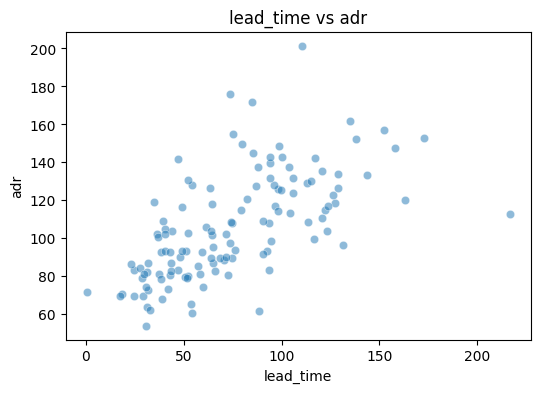

In [19]:
scatterplot(booking_reviews, "lead_time", "adr")

Insights:
- Se observa una ligera relación positiva: mayor anticipación tiende a asociarse con precios más altos.
Sin embargo, la dispersión es elevada.

Conclusión:
La anticipación influye en el precio, pero no es el único factor determinante.

✔ adr vs market_segment

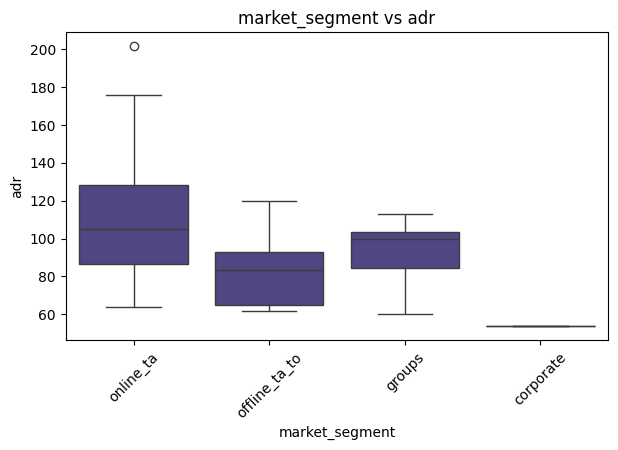

In [20]:
boxplots_bi(booking_reviews, "market_segment", "adr")

Insights:
- *Online TA* presenta los valores de *ADR* más altos.
- *Corporate* muestra precios más bajos y estables.
- *Groups* tienden a tarifas más reducidas (posibles descuentos por volumen).

Conclusión:
Los canales online son los más rentables, mientras que los segmentos corporativos aportan estabilidad más que margen.

✔ adr vs customer_type

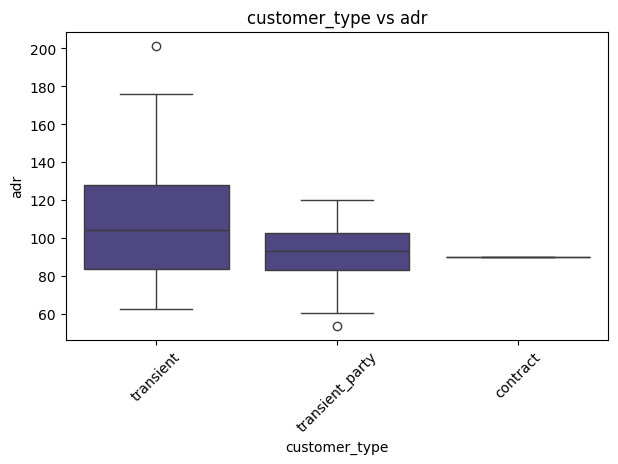

In [21]:
boxplots_bi(booking_reviews, "customer_type", "adr")

Insights:
- *Transient* presenta los valores de *ADR* más altos y mayor variabilidad.
- *Transient Party* muestra precios ligeramente más bajos y más estables.
- *Contract* tiene el *ADR* más bajo y prácticamente sin variación.

Conclusión:
Los clientes *Transient* son los más rentables pero menos predecibles, mientras que *Contract* aporta estabilidad a costa de menor ingreso.

**2.5. Satisfacción (¿qué opinan?)** ⭐

✔ average_score vs adr

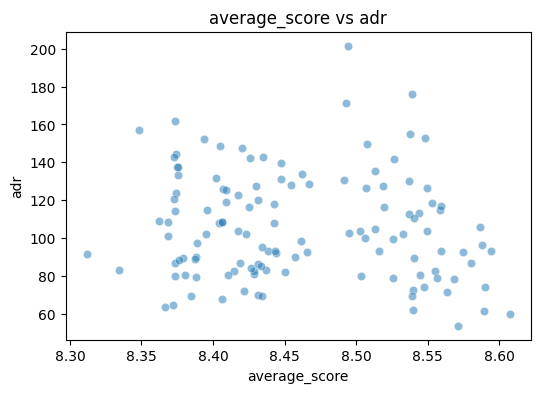

In [22]:
scatterplot(booking_reviews, "average_score", "adr")

Insights:
- No existe una relación clara entre precio y puntuación.
- Clientes que pagan más no necesariamente valoran mejor.

Conclusión:
El precio no es un buen predictor de satisfacción, lo que indica que otros factores (servicio, expectativas) son más relevantes.

✔ score vs hotel

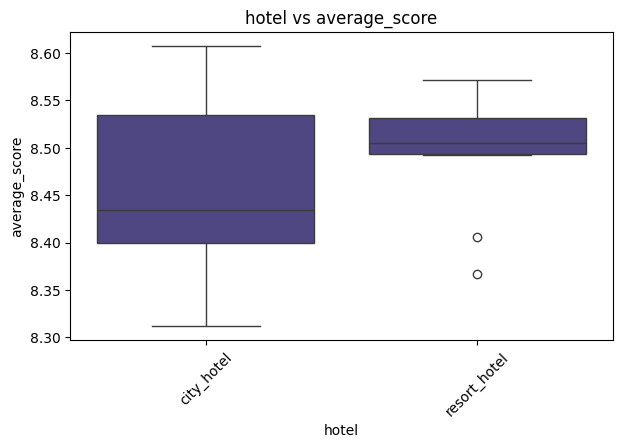

In [23]:
boxplots_bi(booking_reviews, "hotel", "average_score")

Insights:
- Los hoteles tipo *Resort* presentan puntuaciones ligeramente superiores.
- La diferencia no es extrema, pero sí consistente.

Conclusión:
El tipo de hotel influye en la experiencia, posiblemente por el enfoque más orientado a ocio.

✔ total_number_of_reviews vs score

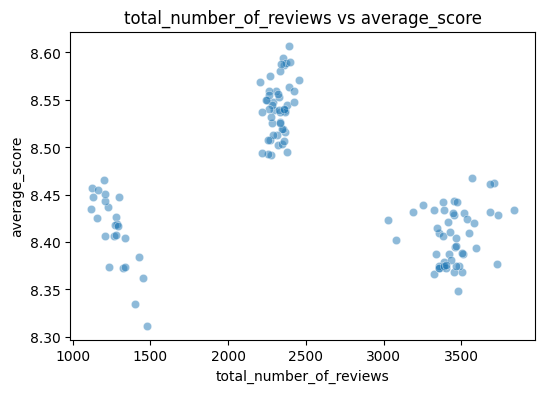

In [24]:
scatterplot(booking_reviews, "total_number_of_reviews", "average_score")

Insights:
- No se observa una relación clara entre el número de reviews y la puntuación media.
- Los hoteles con más reviews (≈3000–3700) no tienen mejores scores; de hecho, tienden a valores ligeramente más bajos.
- Los scores más altos se concentran en un rango intermedio de reviews (≈2200–2600).

Conclusión:
La popularidad (número de reviews) no implica mayor satisfacción; incluso puede asociarse a valoraciones ligeramente más bajas, posiblemente por mayor diversidad de opiniones.

✔ lead_time vs average_score

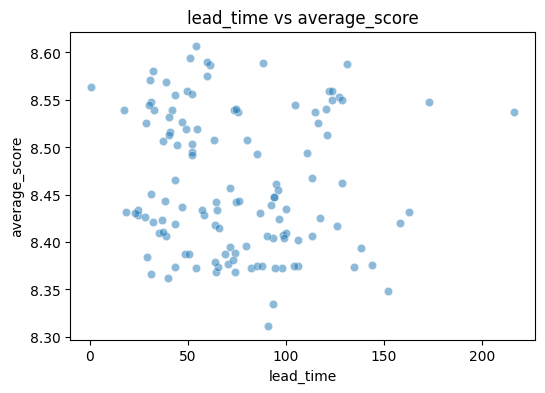

In [25]:
scatterplot(booking_reviews, "lead_time", "average_score")

Insights:
- No se observa una relación clara y fuerte entre la antelación de reserva y la puntuación media del hotel.
- Las puntuaciones se mantienen bastante estables (≈8.3–8.6) a lo largo de todo el rango de lead time.
- En las antelaciones de reserva más altas (≈120–220 días) no se aprecia una mejora en la valoración; incluso hay ligera dispersión hacia valores medios.
- Los scores más altos aparecen distribuidos en distintos niveles de antelación, sin concentrarse en un rango específico.

Conclusión:
El tiempo de antelación con el que se realiza la reserva no parece ser un factor determinante en la satisfacción del cliente. Las valoraciones son bastante consistentes independientemente del lead time, lo que sugiere que la calidad percibida del hotel depende más de otros factores (servicio, experiencia, precio, etc.) que del momento de la reserva.

**2.6 Fidelización** 💎

✔ booking_changes vs customer_type

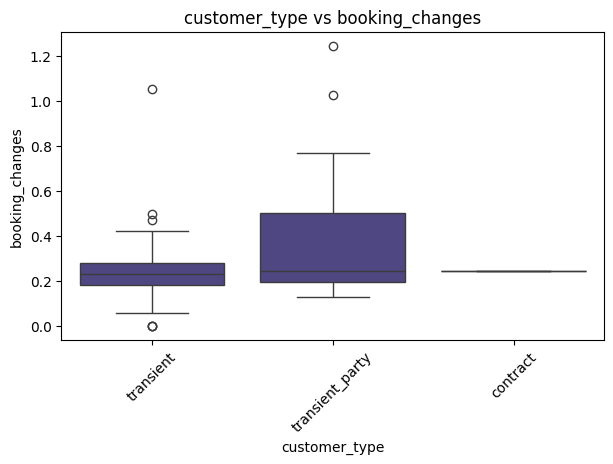

In [26]:
boxplots_bi(booking_reviews, "customer_type", "booking_changes")

Insights:
- *Transient party* presenta mayor número de cambios en reservas.
- Los clientes más estructurados muestran comportamientos más estables.

Conclusión:
Los clientes no fidelizados generan más incertidumbre operativa.

---
### <span style="color:darkgray">**4. Análisis multivariado**</span>  

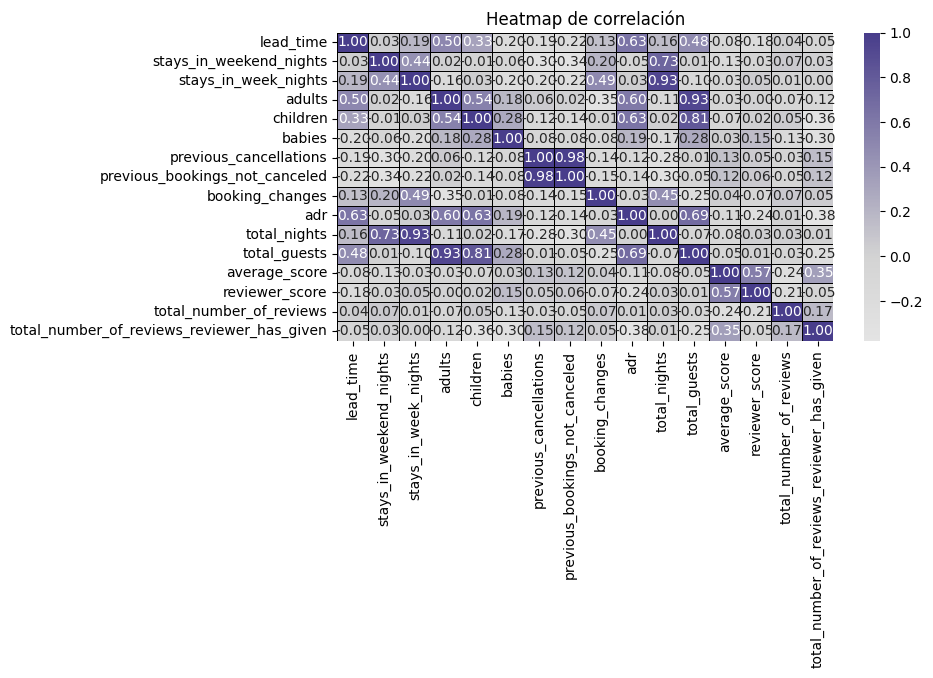

In [27]:
# Llamamos a la función que nos dibuja el heatmap guardada en el archivo de soporte
grafica_correlacion(booking_reviews)

🟣 **Correlaciones más fuertes (positivas):**

**`adults` ↔ `total_guests` (~0.93)**

- Más adultos implican directamente más huéspedes.

**`stays_in_week_nights` ↔ `total_nights` (~0.93)**

- Las noches entre semana dominan el total de noches.

**`stays_in_weekend_nights` ↔ `total_nights` (~0.73)**

- Las noches de fin de semana también influyen bastante en el total.

**`previous_cancellations` ↔ `previous_bookings_not_canceled` (~0.98)**

- Ambas variables reflejan el nivel de actividad del cliente: quienes reservan más tienden tanto a cancelar como a completar más reservas.

🟢 **Correlaciones moderadas:**

**`lead_time` ↔ `adr` (~0.63)**

- Reservas con más anticipación tienden a tener precios distintos.

`booking_changes` ↔ `adr` (~0.45)

- Cambios en la reserva se asocian moderadamente con el precio.

`total_guests` ↔ `adr` (~0.39)

- Más huéspedes pueden implicar mayor precio promedio.

⚪ **Correlaciones débiles o casi nulas:**

`babies`, `children`, `average_score`, `reviewer_score`

- Presentan valores cercanos a 0 → poca relación lineal con otras variables.

🔴 **Correlaciones negativas:**

`previous_cancellations` ↔ `` (~-0.12)

- Más cancelaciones se asocian ligeramente con precios más bajos.

`lead_time` ↔ `total_nights` (~-0.16)

- Reservas anticipadas tienden a ser ligeramente más cortas.


---
---
## <span style="color:gray">**Insights**</span> 💡

El análisis revela un negocio hotelero claramente impulsado por un **perfil de cliente muy definido**: parejas que viajan por ocio, realizan estancias cortas y reservan principalmente a través de agencias de viajes online. Este patrón se repite de forma consistente en la mayoría de las variables, dibujando una operación altamente estandarizada pero dependiente de intermediarios externos.

A lo largo del estudio se observa que la **duración de las estancias** se concentra casi siempre entre dos y cuatro noches, lo que refuerza la idea de un producto orientado a escapadas urbanas más que a viajes largos. Este comportamiento no parece estar influenciado por el momento de la reserva, ya que la antelación con la que se realiza el booking no modifica significativamente ni la duración ni la experiencia del cliente.

En paralelo, el **análisis de precios** muestra una dinámica interesante: las reservas realizadas con mayor antelación tienden a asociarse ligeramente con precios más altos, aunque con una gran dispersión que indica que el precio depende de múltiples factores adicionales. Sin embargo, lo más llamativo es que este precio no tiene una relación directa con la satisfacción del cliente, que se mantiene estable y alta independientemente del importe pagado.

Cuando observamos los distintos **tipos de clientes**, emerge una dualidad clara. Por un lado, el segmento *Transient* concentra la mayor parte del negocio: es rentable, dinámico y flexible, pero también el más impredecible. Por otro lado, los clientes *Contract* ofrecen estabilidad operativa, aunque con menor capacidad de generar ingresos elevados. Entre ambos extremos, el negocio se apoya principalmente en un flujo constante de clientes no fidelizados.

El **canal de adquisición** refuerza esta dependencia: las agencias de viajes online dominan el panorama, lo que incrementa el volumen de reservas pero reduce el control directo sobre el cliente final. Este ecosistema genera una estructura de ingresos sólida pero vulnerable a cambios externos.

A nivel de **satisfacción**, los resultados son sorprendentemente homogéneos. Las valoraciones se mantienen consistentemente altas, sin importar el precio, la antelación o incluso el volumen de reseñas del hotel. Esto sugiere que la experiencia percibida está influida por factores que no están capturados en los datos, como el servicio, la atención o las expectativas del cliente.

Finalmente, el análisis también revela una limitación importante del propio dataset: existen múltiples variables con muy poca o ninguna variabilidad, lo que reduce su utilidad analítica. Además, algunas métricas de experiencia no son consistentes entre sí debido a diferencias en su origen, lo que obliga a ser cauteloso en su interpretación.

---
---
## <span style="color:gray">**Conclusiones finales**</span> 📝

En conjunto, el negocio se apoya sobre una base sólida de demanda constante, pero altamente dependiente de clientes ocasionales y canales externos. Es un modelo rentable, especialmente en el segmento *Transient*, pero con una volatilidad inherente que limita su previsibilidad.

La gran oportunidad no está en aumentar la demanda, sino en reducir la dependencia de intermediarios y mejorar la fidelización, transformando un modelo reactivo en uno más controlado y sostenible.